<a href="https://colab.research.google.com/github/uditch2003/my/blob/main/predicting_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#predicting customer churn for a subscription service
#
#
#
#
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score, roc_curve

In [ ]:
#load data set
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#check for missing values
print(df.isnull().sum())

#remove rows with missing values
df.dropna(inplace=True)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
#convert the 'TotalCharges' column to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
#fill Na n values in total charges with 0
df['TotalCharges'].fillna(0,inplace=True)

#convert categorical features to numeric using label encoding and one hot encoding
label_encoder=LabelEncoder()
df['gender']=label_encoder.fit_transform(df['gender'])
df['Partner']=label_encoder.fit_transform(df['Partner'])
df['Dependents']=label_encoder.fit_transform(df['Dependents'])
df['PhoneService']=label_encoder.fit_transform(df['PhoneService'])
df['PaperlessBilling']=label_encoder.fit_transform(df['PaperlessBilling'])
df['Churn']=label_encoder.fit_transform(df['Churn'])

#one hot encode categorical columns
df=pd.get_dummies(df,columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'])


In [ ]:
#scale numerical features
scaler=StandardScaler()
df[['tenure','MonthlyCharges','TotalCharges']]=scaler.fit_transform(df[['tenure','MonthlyCharges','TotalCharges']])

In [ ]:
#define feature x and target y
x=df.drop(['customerID','Churn'],axis=1)
y=df['Churn']

#splitting data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



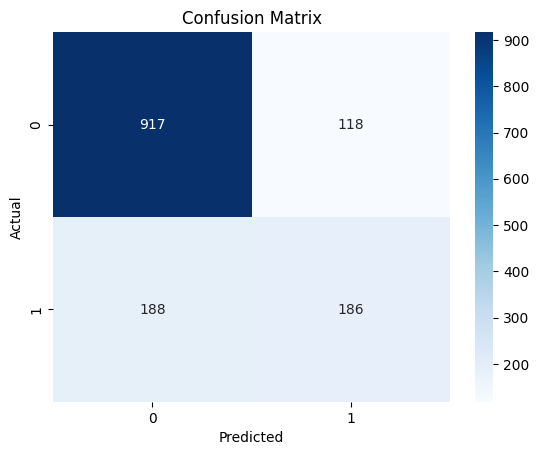

ROC-AUC Score:0.8175


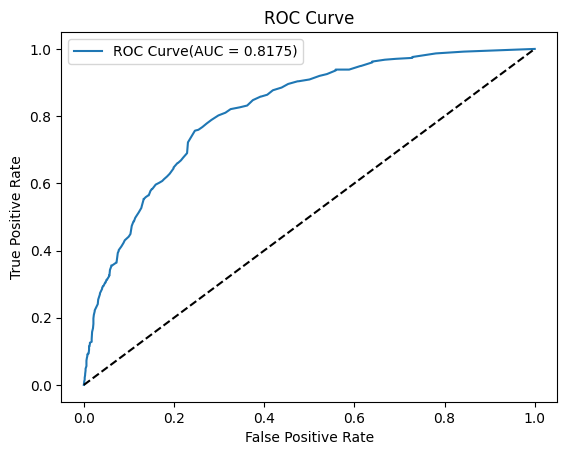

In [ ]:
#initialise RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)

#train the model
rf_model.fit(x_train,y_train)

#make predictions on the test set
y_pred=rf_model.predict(x_test)

#classification report
print(classification_report(y_test,y_pred))

#confusion matrix
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#roc auc score
roc_auc = roc_auc_score(y_test,rf_model.predict_proba(x_test)[:,1])
print(f'ROC-AUC Score:{roc_auc:.4f}')

#roc curve
fpr, tpr, thresholds= roc_curve(y_test,rf_model.predict_proba(x_test)[:,1])
plt.plot(fpr, tpr, label=f'ROC Curve(AUC = {roc_auc:.4})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()